paper: https://www.laboratoryinvestigation.org/article/S0023-6837(23)00201-5/fulltext

In [54]:
import scanpy as sc
import os

datasets = ["GSM6592049_M2.h5ad", "GSM6592052_M5.h5ad", "GSM6592053_M6.h5ad", "GSM6592055_M8.h5ad", "GSM6592059_M13.h5ad"]
filename = datasets[0]
adata = sc.read_h5ad(os.path.join("..", "datasets", filename))
adata = adata[adata.obs["in_tissue"] == True, :]
adata

View of AnnData object with n_obs × n_vars = 1848 × 36386
    obs: 'in_tissue', 'array_row', 'array_col', 'suspension_type', 'assay_ontology_term_id', 'Sample_ID', 'organism_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation', 'cell_type_ontology_term_id', 'is_primary_data', 'treatment', 'donor_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_types', 'genome', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id'
    uns: 'citation', 'schema_reference', 'schema_version', 'spatial', 'title'
    obsm: 'spatial'

# Spatial Transcriptomics Reveal Pitfalls and Opportunities for the Detection of Rare High-Plasticity Breast Cancer Subtypes

## Materials and Methods

### Spatial Transcriptomic Analyses

Each tissue slide analyzed by Visium was given a unique identifier starting with M. The first batch included tissue slides M1 to M11 (CL-like, unstable TNBC, and normal controls), and the second batch included tissue slides M13 to M16 (metaplastic TNBCs).

Space Ranger software (10x Genomics) was used to process the raw data. Stereoscope 18 was used for deconvolution analyses using only the TNBC data from a single-cell breast cancer atlas19 and excluding plasmablasts that were initially found to be overrepresented in deconvolution results (included cell types: cancer epithelial, normal epithelial, endothelial, cancer-associated fibroblasts, T cell, B cell, myeloid, and perivascular-like cells).

### Combining Histopathological Annotations and Spatial Transcriptomics on Fresh Frozen Tissue

All slides were annotated by a breast pathologist (V.C.) to separate tumor/nontumor and epithelial/nonepithelial compartments as well as to eliminate spots corresponding to folded tissue and artifacts. 

[...] we restricted the analysis of stromal spots to the following pathologist annotations, exclusively: fibrosis, fibrosis (peritumoral), fibrous stroma, tumor stroma, and tumor stroma fibrous, the last 2 separated on visual appreciation of the cellular density and collagen abundance in the stroma. 

In [55]:
# important obs columns
# 'pathologist_annotation', 'B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'T-cells', 'stereoscope_annotation'
adata.obs.pathologist_annotation.value_counts()


pathologist_annotation
Tumor stroma with inflammation    853
Tumor cells                       312
Adipose tissue                    259
Tumor stroma fibrous              206
Artifacts                          42
Name: count, dtype: int64

Tumor and stromal spots identified by the pathologist were further refined using scores obtained by RNA-based computational deconvolution. This ensured that only the most enriched spots in the population of interest were analyzed by combining human expertise and computational data mining.

In [56]:
adata.obs.stereoscope_annotation.value_counts()

stereoscope_annotation
B-cells              823
Myeloid              504
CAFs                 255
Cancer Epithelial    222
Normal Epithelial     24
Endothelial           12
PVL                    6
T-cells                2
Name: count, dtype: int64

Tumor spots with a cancer epithelial score <0.1, as attributed by the stereoscope software, were discarded. In addition, spots annotated as tumor by the pathologist in the MpBC_chondroid sample with unusual B cell stereoscope scores >0.1 were also discarded. For spots annotated as stromal by the pathologist, those with either normal epithelial or cancer epithelial scores >0.1 in the stereoscope deconvolution output were discarded.

In [57]:
# What are tumor spots?
discard_1 = (adata.obs['pathologist_annotation'].str.contains('Tumor', case=False, na=False)) & (adata.obs['Cancer Epithelial'] < 0.1)
print(sum(discard_1))

# MpBC_chondroid sample: M15
if "M15" in filename:
    discard_2 = (adata.obs['pathologist_annotation'].str.contains('Tumor', case=False, na=False)) & (adata.obs['B-cells'] > 0.1)
    print(sum(discard_2))

discard_3 = (adata.obs['pathologist_annotation'].str.contains('stroma', case=False, na=False)) & ((adata.obs['Cancer Epithelial'] > 0.1) | (adata.obs['Normal Epithelial'] > 0.1))
print(sum(discard_3))


print("number of discarded spots:", sum(discard_1 | discard_3))

adata.obs["discard"] = discard_1 #| discard_3

958
377
number of discarded spots: 1163


C:\Users\rebec\AppData\Local\Temp\ipykernel_22604\3649237798.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["discard"] = discard_1 #| discard_3


C:\Users\rebec\AppData\Local\Temp\ipykernel_22604\3885826097.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


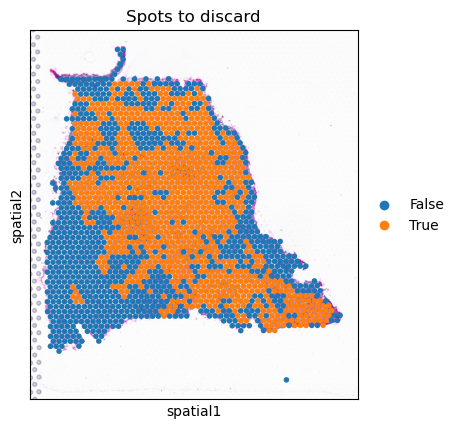

In [58]:
sc.pl.spatial(
    adata,
    color="discard",
    library_id="GSM6592049_M2",
    cmap="viridis",  # or any colormap
    size=1.5,
    title="Spots to discard"
)

### Copy Number Alteration Profiles

Individual spot copy number (CN) profiles were produced with the infercnvPlus tool (https://github.com/CharleneZ95/infercnvPlus, based on inferCNV of the Trinity CTAT project: https://github.com/broadinstitute/inferCNV). For each slide, all spots annotated as either tumoral or epithelial were pooled using epithelial spots as references.

This produced a relative CN measure per gene per spot, which we complied into a major cytoband per spot matrix, by computing the average CN per cytoband. Sample-specific profiles were then obtained by averaging the relative CN measures per cytoband across all spots of each given sample. Comparable profiles were obtained for bulk samples, by averaging per cytoband the segmented logR values reported by FACETS17 analysis, from the WES data of CL-like and unstable samples.

Gain/loss profiles were calculated for each bulk sample by attributing values of 1 (gain), 0 (normal), or -1 (loss) to each cytoband, according to whether their mean logR exceeded the median logR of the sample ± 0.6, as implemented by Van Loo et al.21 A threshold was used to calculate similar gain/loss profiles in Visium samples, according to whether the cytoband CNA score exceeded the threshold. Its value was optimized to minimize the pairwise distance across all cytobands between the bulk-derived and SpaT-derived gain/loss profiles for the 4 unstable tumors, which provided the most reliable and informative data. CN profiles were calculated for all Molecular Taxonomy of Breast Cancer International Consortium IntClusters (METABRIC) using the difference between gains and losses (number of gains minus number of losses) reported for each gene in each cluster and then summed per cytoband as for our other CN profiles. Correlation- based distances were obtained by calculating the Pearson R correlation between 2 samples, minus 1, and then divided by -2. This gives a minimum distance of 0 for perfectly correlated samples and a maximum distance of 1 for perfectly anticorrelated samples.

### Differential Expression Analyses on Spatial Tanscriptomics Data

All tumor samples were first individually normalized using the SCTransform function of the Seurat R package. All 11 samples were then merged together and renormalized using the SCTransform function, resulting in a matrix of 22,058 genes by 14,905 spots. 

We don't use this preprocessing, because they only need tumor cells (with a high certainty), but we want all types of cells.

We discard Artifacts!